<a href="https://colab.research.google.com/github/itssssarah/csc212phase2/blob/main/Zid_case_study_TODO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h1>Beyond Experience × Zid</h1>

<h2>دراسة حالة: التنبؤ بالطلب خلال موسم اليوم الوطني السعودي</h2>

<h3>مرحبًا بك!</h3>

<p>
خلال هذه الدراسة، ستعمل بصفتك <strong>أخصائي تعلم آلة (Machine Learning Specialist)</strong> لدى متجر إلكتروني يعمل على منصة زد.
</p>

<p>
خلال المواسم التجارية، يواجه التجار تحديًا يتمثل في تحديد الكميات المناسبة من المنتجات قبل بدء الموسم. فقد يؤدي تقدير الطلب بأقل من الواقع إلى نفاد المخزون، بينما قد يؤدي تقديره بأكثر من الطلب الفعلي إلى بقاء كميات غير مباعة بعد انتهاء الموسم.
</p>

<p>
تتمثل مهمتك في تحليل بيانات المبيعات السابقة لمساعدة التاجر على الاستعداد لموسم اليوم الوطني السعودي، وذلك من خلال الإجابة عن سؤالين رئيسيين:
</p>

<ul>
  <li><strong>كم وحدة ينبغي توفيرها من كل منتج؟</strong></li>
  <li><strong>ومتى يُفضل إطلاق الحملة الترويجية؟</strong></li>
</ul>

<p>
وللإجابة عن هذين السؤالين، ستستكشف البيانات، وتتعرّف على الأنماط الموسمية، ثم تبني نموذجًا للتنبؤ بالطلب وتحول نتائجه إلى توصيات عملية تساعد التاجر على اتخاذ القرار.
</p>

</div>


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>التعرّف على بيانات دراسة الحالة (Dataset Overview)</h2>

<p>
تعتمد دراسة الحالة على ثلاثة ملفات بيانات، يوفّر كل منها نوعًا مختلفًا من المعلومات التي سنستخدمها معًا لبناء نموذج التنبؤ بالطلب.
</p>

<p>
يحتوي ملف <code>orders.csv</code> على سجلات المبيعات التاريخية <strong>(Historical Sales Records)</strong>، ويتضمن معلومات مثل تاريخ الطلب، والمنتج، والكمية المباعة، وسعر الوحدة، ونسبة الخصم، والمدينة، وقناة الشراء.
</p>

<p>
أما ملف <code>products.csv</code>، فيحتوي على معلومات المنتجات <strong>(Product Information)</strong>، مثل اسم المنتج، وفئته، وتكلفة الوحدة، وتاريخ إطلاقه في المتجر.
</p>

<p>
ويحتوي ملف <code>calendar.csv</code> على تقويم زمني <strong>(Calendar)</strong> يتضمن تاريخ كل يوم، إلى جانب مؤشرات تحدد ما إذا كان اليوم يقع ضمن موسم اليوم الوطني، أو شهر رمضان، أو أيام العيد، أو أحد أيام العروض الترويجية.
</p>

</div>


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>تحميل ملفات البيانات (Data Loading)</h2>

<p>
تبدأ المهمة بتجهيز بيانات المتجر للتحليل، من خلال قراءة ملفات البيانات الثلاثة وتحويل أعمدة التواريخ إلى الصيغة المناسبة، بما يتيح تحليل المبيعات عبر الزمن والتعرّف على الأنماط الموسمية المرتبطة باليوم الوطني.
</p>

</div>

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (13, 4)
RANDOM_STATE = 42

orders   = pd.read_csv("orders.csv",   parse_dates=["order_date"])
products = pd.read_csv("products.csv", parse_dates=["launch_date"])
calendar = pd.read_csv("calendar.csv", parse_dates=["date"])

for name, frame in [("orders", orders), ("products", products), ("calendar", calendar)]:
    print(f"{name:9s} {frame.shape}")

orders    (118602, 8)
products  (25, 5)
calendar  (771, 5)


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>استعراض البيانات (Data Preview)</h2>

<p>
سنستعرض عينة من كل ملف للتعرّف على محتوى البيانات وأبرز الأعمدة قبل البدء في تحليلها.
</p>

</div>

In [ ]:
display(orders.head())
display(products.head())
display(calendar.head())

,order_id,order_date,product_id,quantity,unit_price,discount_pct,city,channel
0,O100001,2024-07-01 20:00:00,P001,1,45,0,Makkah,app
1,O100002,2024-07-01 18:00:00,P001,1,45,0,Riyadh,app
2,O100003,2024-07-01 13:00:00,P001,2,45,0,Tabuk,app
3,O100004,2024-07-01 19:00:00,P001,2,45,0,Riyadh,web
4,O100005,2024-07-01 15:00:00,P001,2,45,0,Jeddah,app


,product_id,product_name,category,cost_price,launch_date
0,P001,"Saudi flag (large, outdoor)",Décor,18,2023-05-01
1,P002,Saudi flag (desk size),Décor,5,2023-05-01
2,P003,Green LED string lights 10m,Décor,14,2023-08-10
3,P004,National Day balloon & banner kit,Décor,22,2023-08-10
4,P005,Falcon wall art (metal),Décor,80,2023-11-02


,date,is_national_day_season,is_ramadan,is_eid,is_promo_day
0,2024-07-01,0,0,0,0
1,2024-07-02,0,0,0,0
2,2024-07-03,0,0,0,0
3,2024-07-04,0,0,0,0
4,2024-07-05,0,0,0,0


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>فحص بنية البيانات (Data Inspection)</h2>

<p>
قبل البدء في التحليل، سنتحقق من بنية ملفات البيانات وأنواع الأعمدة التي تتضمنها.
</p>

</div>

In [ ]:
# فحص بنية كل جدول

for name, frame in [
    ("Orders", orders),
    ("Products", products),
    ("Calendar", calendar)
]:
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(frame.info())

Orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118602 entries, 0 to 118601
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      118602 non-null  object        
 1   order_date    118602 non-null  datetime64[ns]
 2   product_id    118602 non-null  object        
 3   quantity      118602 non-null  int64         
 4   unit_price    118602 non-null  int64         
 5   discount_pct  118602 non-null  int64         
 6   city          118602 non-null  object        
 7   channel       118602 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 7.2+ MB
None
Products
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    25 non-null     object        
 1   product_name  25 non-null     obj

<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>فحص جودة البيانات (Data Quality Check)</h2>

<p>
قبل استخدام البيانات في التحليل، سنتحقق من جودتها من خلال فحص القيم المفقودة والسجلات المكررة، إذ قد تؤثر هذه المشكلات في دقة التحليل ونتائج النموذج.
</p>

</div>

In [ ]:
# TODO 1:
# أكمل فحص القيم المفقودة والسجلات المكررة في كل جدول.

for name, frame in [
    ("Orders", orders),
    ("Products", products),
    ("Calendar", calendar)
]:

    # ← احسب إجمالي القيم المفقودة في الجدول
    missing    = frame.________().sum().sum()

    # ← احسب عدد الصفوف المكررة في الجدول
    duplicated = frame.____________().sum()

    print(f"{name:10s} | missing: {missing:>3} | duplicated: {duplicated:>3}")

Orders     | missing:   0 | duplicated:   0
Products   | missing:   0 | duplicated:   0
Calendar   | missing:   0 | duplicated:   0


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>تكامل البيانات (Data Integration)</h2>

<p>
تبدأ هذه المرحلة بربط بيانات الطلبات بالمنتجات والتقويم، للحصول على سجل متكامل لكل عملية بيع قبل البدء في مرحلة التحليل.
</p>

<p>
وتتم عملية الربط عبر ثلاث خطوات رئيسية:
</p>

<ul>
  <li><strong>إضافة معلومات المنتجات:</strong> ربط كل طلب بالمنتج الخاص به لإضافة بياناته، مثل الفئة والتكلفة.</li>

  <li><strong>توحيد صيغة التاريخ:</strong> الاكتفاء بتاريخ الطلب دون وقت تنفيذه، ليتوافق مع الصيغة المستخدمة في جدول التقويم.</li>

  <li><strong>إضافة معلومات التقويم:</strong> ربط كل طلب بالتاريخ المقابل له في جدول التقويم للتعرّف على الموسم أو المناسبة والعروض الترويجية المرتبطة بذلك اليوم.</li>
</ul>

<p>
ينتج عن ذلك جدول موحّد يجمع تفاصيل الطلبات والمنتجات والتقويم، ويشكّل الأساس للخطوات التحليلية التالية.
</p>

</div>

In [ ]:
# TODO 2:
# أكمل خطوات تكامل البيانات:
# 1- ادمج بيانات الطلبات مع بيانات المنتجات، بالاعتماد على معرّف المنتج `product_id`.
# 2- أنشئ عمودًا للتاريخ فقط، باستخراجه من تاريخ ووقت الطلب `order_date`.
# 3- ادمج الناتج مع بيانات التقويم، بالاعتماد على عمود التاريخ `date`.

merged_df = orders.merge(________, on="____________", how="left")


merged_df["date"] = merged_df["order_date"].dt.____________()


final_df = merged_df.merge(________, on="______", how="left")

print("final_df:", final_df.shape)
final_df.head()

final_df: (118602, 17)


,order_id,order_date,product_id,quantity,unit_price,discount_pct,city,channel,product_name,category,cost_price,launch_date,date,is_national_day_season,is_ramadan,is_eid,is_promo_day
0,O100001,2024-07-01 20:00:00,P001,1,45,0,Makkah,app,"Saudi flag (large, outdoor)",Décor,18,2023-05-01,2024-07-01,0,0,0,0
1,O100002,2024-07-01 18:00:00,P001,1,45,0,Riyadh,app,"Saudi flag (large, outdoor)",Décor,18,2023-05-01,2024-07-01,0,0,0,0
2,O100003,2024-07-01 13:00:00,P001,2,45,0,Tabuk,app,"Saudi flag (large, outdoor)",Décor,18,2023-05-01,2024-07-01,0,0,0,0
3,O100004,2024-07-01 19:00:00,P001,2,45,0,Riyadh,web,"Saudi flag (large, outdoor)",Décor,18,2023-05-01,2024-07-01,0,0,0,0
4,O100005,2024-07-01 15:00:00,P001,2,45,0,Jeddah,app,"Saudi flag (large, outdoor)",Décor,18,2023-05-01,2024-07-01,0,0,0,0


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>إعداد البيانات (Data Preparation)</h2>

<p>
بعد الانتهاء من <strong>تكامل البيانات (Data Integration)</strong>، أصبحت جميع المعلومات اللازمة للتحليل متاحة في مجموعة بيانات واحدة. إلا أن شكل البيانات الحالي لا يزال غير مناسب لبناء نموذج التنبؤ بالطلب.
</p>

<p>
تُسجل البيانات الحالية كل عملية بيع كسجل مستقل، بينما يحتاج نموذج التنبؤ إلى معرفة كمية الطلب <strong>لكل منتج في كل يوم</strong>. لذلك، سنحوّل سجلات المبيعات إلى جدول يومي، ثم ننشئ سجلًا لكل منتج في كل يوم، بما في ذلك الأيام التي لم تُسجل فيها أي مبيعات، حتى تمثل البيانات الطلب اليومي لكل منتج بصورة كاملة.
</p>

<p>
بعد ذلك، سنعيد إضافة معلومات المنتجات والتقويم إلى الجدول الناتج، ثم نستبعد الأيام التي تسبق تاريخ إطلاق كل منتج، حتى تقتصر البيانات على الفترة التي كان المنتج متاحًا فيها للبيع.
</p>

<p>
وبنهاية هذه المرحلة، سنحصل على مجموعة بيانات جاهزة للتحليل الاستكشافي وبناء نموذج تعلم الآلة.
</p>

</div>

In [ ]:
# إعداد البيانات: تحويل سجلات البيع إلى صف لكل منتج في كل يوم

# 1- إجمالي الكمية المباعة لكل منتج في كل يوم

daily = final_df.groupby(["date", "product_id"], as_index=False)["quantity"].sum()

# 2- جميع التركيبات الممكنة بين الأيام والمنتجات

grid = pd.MultiIndex.from_product(
    [calendar["date"], products["product_id"]],
    names=["date", "product_id"]
).to_frame(index=False)

# 3- إضافة المبيعات، والأيام بلا مبيعات تُسجَّل صفرًا

df = (
    grid
    .merge(daily,    on=["date", "product_id"], how="left")
    .fillna({"quantity": 0})
    .merge(products, on="product_id")
    .merge(calendar, on="date")
)

# 4- استبعاد السجلات السابقة لتاريخ إطلاق المنتج

df = df[df["date"] >= df["launch_date"]].copy()

print("daily:", daily.shape)
print("df   :", df.shape)
df.head()

daily: (18360, 3)
df   : (18547, 11)


,date,product_id,quantity,product_name,category,cost_price,launch_date,is_national_day_season,is_ramadan,is_eid,is_promo_day
0,2024-07-01,P001,12.0,"Saudi flag (large, outdoor)",Décor,18,2023-05-01,0,0,0,0
1,2024-07-01,P002,9.0,Saudi flag (desk size),Décor,5,2023-05-01,0,0,0,0
2,2024-07-01,P003,8.0,Green LED string lights 10m,Décor,14,2023-08-10,0,0,0,0
3,2024-07-01,P004,5.0,National Day balloon & banner kit,Décor,22,2023-08-10,0,0,0,0
4,2024-07-01,P005,3.0,Falcon wall art (metal),Décor,80,2023-11-02,0,0,0,0


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>التحليل الاستكشافي للبيانات (Exploratory Data Analysis - EDA)</h2>

<p>
بعد إعداد البيانات، أصبحت مجموعة البيانات جاهزة للاستكشاف. يهدف <strong>التحليل الاستكشافي للبيانات (Exploratory Data Analysis - EDA)</strong> إلى الإجابة عن الأسئلة التي يحتاج التاجر إلى فهمها قبل اتخاذ قرارات المخزون، مثل تحديد المنتجات الأعلى طلبًا، واكتشاف الأنماط الموسمية، والتعرف على أي سلوك غير اعتيادي قد يؤثر في دقة التنبؤ.
</p>

<p>
سنستخدم الرسوم البيانية والإحصاءات الوصفية لتحليل الطلب اليومي، ومقارنة أداء المنتجات، وفهم توزيع المبيعات، تمهيدًا لاستخلاص الخصائص التي ستُستخدم في مرحلة <strong>هندسة الخصائص (Feature Engineering)</strong>.
</p>

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

**<h3>الأنماط الموسمية في سلوك الشراء</h3>**

<p>
يتأثر الطلب في المتاجر الإلكترونية بأنماط متكررة، بعضها أسبوعي وبعضها يرتبط بالمواسم. في هذا الجزء، سنستكشف توزيع الطلب على أيام الأسبوع، ثم نقارن توقيت الشراء خلال شهر رمضان بالأيام الاعتيادية.
</p>

</div>

In [ ]:
#  توزيع الكمية المباعة على أيام الأسبوع
orders["day_of_week"] = orders["order_date"].dt.dayofweek

weekly_share = orders.groupby("day_of_week")["quantity"].sum()
weekly_share = (weekly_share / weekly_share.sum() * 100).round(1)

DAY_NAMES = ["الاثنين", "الثلاثاء", "الأربعاء", "الخميس", "الجمعة", "السبت", "الأحد"]
weekly_share.index = DAY_NAMES

print("حصة كل يوم من إجمالي المبيعات (%)")
print(weekly_share.to_string())
print("\nالجمعة والسبت معًا:", round(weekly_share.loc["الجمعة"] + weekly_share.loc["السبت"], 1), "%")

# أثر رمضان على توقيت الشراء خلال اليوم
orders["hour"] = orders["order_date"].dt.hour
orders["date"] = orders["order_date"].dt.normalize()

orders_with_calendar = orders.merge(calendar, on="date", how="left")

ramadan_hour = orders_with_calendar.loc[orders_with_calendar["is_ramadan"] == 1, "hour"].mean()
normal_hour  = orders_with_calendar.loc[orders_with_calendar["is_ramadan"] == 0, "hour"].mean()

print("\nمتوسط ساعة الطلب في رمضان:", round(ramadan_hour, 1))
print("متوسط ساعة الطلب في غير رمضان:", round(normal_hour, 1))

حصة كل يوم من إجمالي المبيعات (%)
الاثنين     13.1
الثلاثاء    12.8
الأربعاء    12.8
الخميس      12.8
الجمعة      17.9
السبت       17.6
الأحد       13.0

الجمعة والسبت معًا: 35.5 %

متوسط ساعة الطلب في رمضان: 2.1
متوسط ساعة الطلب في غير رمضان: 16.3


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<p>
تشير النتائج إلى تركز نسبة ملحوظة من الطلب في يومي الجمعة والسبت، كما يظهر انتقال متوسط وقت الشراء إلى ساعات متأخرة خلال شهر رمضان مقارنة بالأيام الاعتيادية، مما يؤكد وجود أنماط زمنية متكررة في سلوك العملاء.
</p>

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

**<h3>الموسمية على مستوى المنتج والفئة</h3>**

<p>
قد لا يظهر أثر الموسم بالدرجة نفسها على جميع الفئات والمنتجات. لذلك، سنقارن أداء الفئات أولًا، ثم نحلل متوسط الطلب لكل منتج داخل الموسم وخارجه لمعرفة أين يظهر أثر الموسم بصورة أوضح.
</p>

</div>

حصة الفئات من المبيعات:


,عادي %,موسم %,الفرق
category,,,
Accessories,20.6,20.4,-0.2
Apparel,17.4,18.3,0.9
Décor,35.3,37.2,1.9
Gifts,26.7,24.1,-2.6


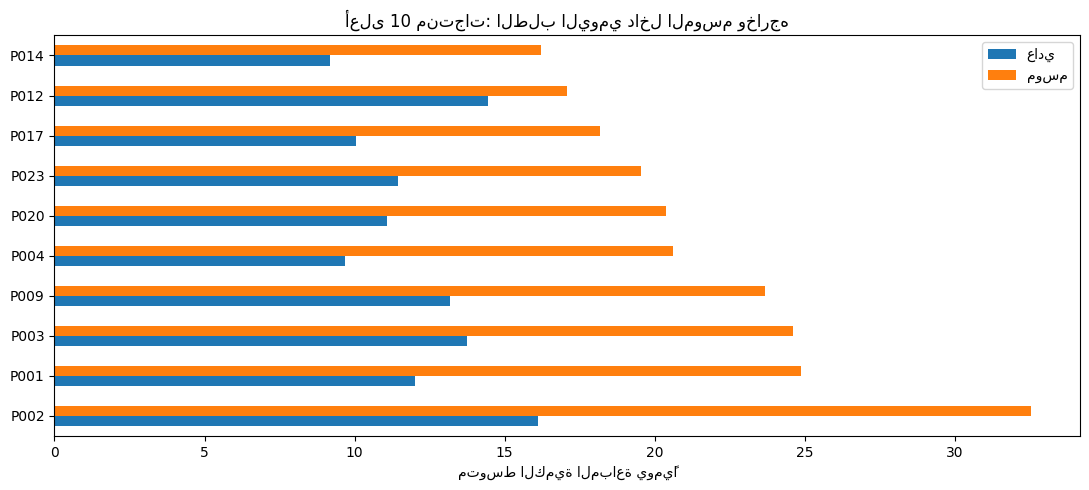

,product_name,عادي,موسم,المضاعف
product_id,,,,
P002,Saudi flag (desk size),16.10,32.55,2.02
P001,"Saudi flag (large, outdoor)",12.03,24.88,2.07
P003,Green LED string lights 10m,13.74,24.60,1.79
P009,SA flag mug,13.17,23.67,1.80
P004,National Day balloon & banner kit,9.67,20.62,2.13
P020,Face-paint & stickers pack,11.10,20.38,1.84
P023,Green LED wristbands (5-pack),11.46,19.55,1.71
P017,'KSA 96' t-shirt,10.04,18.19,1.81
P012,Personalized keychain (name),14.45,17.10,1.18


In [ ]:
# أثر الموسم على مستوى الفئة مقابل مستوى المنتج

seasonal = df[df["is_national_day_season"] == 1]
regular  = df[df["is_national_day_season"] == 0]

# 1) حصة كل فئة من إجمالي المبيعات
cat_season  = seasonal.groupby("category")["quantity"].sum()
cat_regular = regular.groupby("category")["quantity"].sum()

category_view = pd.DataFrame({
    "عادي %": (cat_regular / cat_regular.sum() * 100).round(1),
    "موسم %": (cat_season  / cat_season.sum()  * 100).round(1),
})
category_view["الفرق"] = (category_view["موسم %"] - category_view["عادي %"]).round(1)

print("حصة الفئات من المبيعات:")
display(category_view)

# 2) متوسط الطلب اليومي لكل منتج داخل الموسم وخارجه
prod = pd.DataFrame({
    "عادي":  regular.groupby("product_id")["quantity"].mean(),
    "موسم":  seasonal.groupby("product_id")["quantity"].mean(),
})
prod["المضاعف"] = (prod["موسم"] / prod["عادي"]).round(2)
prod = prod.join(products.set_index("product_id")["product_name"])
top = prod.sort_values("موسم", ascending=False).head(10)

ax = top[["عادي", "موسم"]].plot(kind="barh", figsize=(11, 5))
ax.set_xlabel("متوسط الكمية المباعة يوميًا")
ax.set_ylabel("")
plt.title("أعلى 10 منتجات: الطلب اليومي داخل الموسم وخارجه")
plt.tight_layout(); plt.show()

display(top[["product_name", "عادي", "موسم", "المضاعف"]].round(2))

<div dir="rtl" style="text-align: right; line-height: 1.9;">

**<h3>اتجاه الطلب عبر الزمن</h3>**

<p>
بعد دراسة أثر الموسم، سنستعرض تغير إجمالي الطلب اليومي عبر الفترة الزمنية، ثم نتعرف على المنتجات الأكثر مساهمة في إجمالي المبيعات.
</p>

</div>

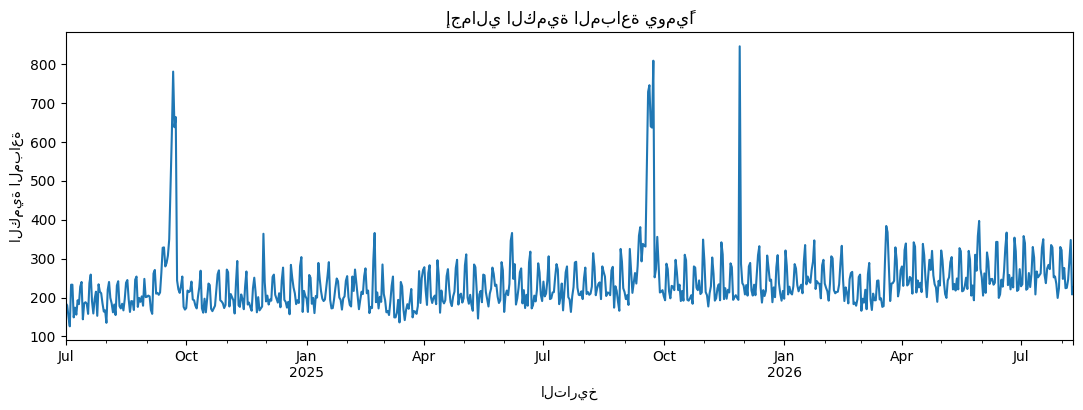

In [ ]:
# إجمالي الكمية المباعة يوميًا

daily_total = (
    df.groupby("date")["quantity"]
      .sum()
      .sort_index()
)

daily_total.plot()

plt.title("إجمالي الكمية المباعة يوميًا")
plt.xlabel("التاريخ")
plt.ylabel("الكمية المباعة")
plt.show()

In [ ]:
# TODO 3:
# حدد أعلى 10 منتجات من حيث إجمالي الكمية المباعة.

top_products = (
    df.groupby(["product_id", "product_name"], as_index=False)["quantity"]
      .____()
      .sort_values("________", ascending=False)
      .head(____)
)

display(top_products)

,product_id,product_name,quantity
1,P002,Saudi flag (desk size),13102.0
11,P012,Personalized keychain (name),11250.0
2,P003,Green LED string lights 10m,11052.0
8,P009,SA flag mug,10597.0
0,P001,"Saudi flag (large, outdoor)",9815.0
22,P023,Green LED wristbands (5-pack),9013.0
19,P020,Face-paint & stickers pack,8946.0
6,P007,Scented candle set (oud),8447.0
16,P017,'KSA 96' t-shirt,8086.0
3,P004,National Day balloon & banner kit,7914.0


<div dir="rtl" style="text-align: right; line-height: 1.9;">

**<h3>القيم الشاذة (Outlier Detection)</h3>**

<p>
قد تتضمن بيانات المبيعات أيامًا يرتفع فيها الطلب بصورة غير اعتيادية. سنستخدم أسلوب <strong>IQR</strong> لتحديد هذه الأيام قبل البحث عن أسبابها.
</p>

</div>

In [ ]:
# استكشاف القيم الشاذة في إجمالي الطلب اليومي باستخدام IQR

q1 = daily_total.quantile(0.25)
q3 = daily_total.quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

outlier_days = daily_total[daily_total > upper_bound]

# مقارنة الأيام الشاذة بوسيط الطلب اليومي لمعرفة حجم الارتفاع في الطلب
median_demand = daily_total.median()

outlier_report = pd.DataFrame({
    "quantity": outlier_days,
    "multiplier": (outlier_days / median_demand).round(1),
})

print("الوسيط:", median_demand)
display(outlier_report.sort_values("quantity", ascending=False))

الوسيط: 220.0


,quantity,multiplier
date,,
2025-11-28,846.0,3.8
2025-09-23,809.0,3.7
2024-09-21,781.0,3.6
2025-09-20,746.0,3.4
2025-09-19,729.0,3.3
2024-09-23,664.0,3.0
2025-09-21,640.0,2.9
2024-09-22,638.0,2.9
2025-09-22,637.0,2.9


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h3>تحديد موعد إطلاق الحملة الترويجية</h3>

<p>
لاختيار التوقيت الأنسب لإطلاق الحملة، سنتتبع الطلب خلال الفترة التي تسبق اليوم الوطني، بهدف رصد بداية ازدياد الإقبال على المنتجات.
</p>

</div>

In [ ]:
# TODO 4:
# لكل من عامي 2024 و2025:
# 1- احسب متوسط الطلب اليومي خلال الفترة من 1 إلى 25 أغسطس ليكون المستوى المرجعي.
# 2- حدّد أول يوم في سبتمبر يتجاوز فيه الطلب المستوى المرجعي بأكثر من 50%.

daily_total = df.groupby("date")["quantity"].sum()

for year in [2024, 2025]:

    august_baseline = daily_total[f"{year}-08-01":f"{year}-08-25"].________()

    september = daily_total[f"{year}-09-01":f"{year}-09-25"]

    ramp_up_day = september[september > august_baseline * ______].index.____()

    print(year,
          "| المستوى المرجعي:", round(august_baseline),
          "| بداية ازدياد الطلب:", ramp_up_day.date())

2024 | المستوى المرجعي: 197 | بداية الارتفاع: 2024-09-13
2025 | المستوى المرجعي: 235 | بداية الارتفاع: 2025-09-12


<div dir="rtl" style="text-align: right; line-height: 1.9;">

**<h3>حالات خاصة في البيانات</h3>**

<p>
إلى جانب الأنماط الموسمية، قد تتضمن البيانات حالات خاصة قد تؤثر في أداء النموذج إذا لم تُفسر بصورة صحيحة. سنستعرض في الأجزاء التالية أبرز هذه الحالات.
</p>

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

**<h3>حالات تحتاج إلى معالجة خاصة</h3>**

<p>
إلى جانب الأنماط العامة التي ظهرت خلال التحليل، تتضمن البيانات بعض الحالات التي تحتاج إلى تفسير ومعالجة قبل بناء النموذج.
</p>

<p>
سنستعرض ثلاث حالات: انقطاع المخزون، والحدث الترويجي غير المتكرر، والمنتجات حديثة الإطلاق. وتختلف طريقة التعامل مع كل حالة بحسب أثرها في البيانات والمعلومات المتاحة عنها.
</p>

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

**<h4>انقطاع المخزون</h4>**

<p>
قد تظهر المبيعات بقيمة صفرية رغم استمرار الطلب الفعلي على المنتج، وذلك عند نفاد المخزون. سنحلل سلوك أحد المنتجات للتحقق من هذه الحالة.
</p>

</div>

In [ ]:
# TODO 5:
# اعرض الكمية المباعة يوميًا من المنتج P004 بين 2025-08-25 و 2025-09-30،
# ثم احسب عدد الأيام التي بلغت فيها الكمية صفرًا.

p004 = daily[daily["product_id"] == "________"].set_index("date")["quantity"]

window = pd.date_range("2025-08-25", "2025-09-30")


series = p004.reindex(window, fill_value=____)


zero_days = series[series == ____]

print("عدد الأيام بصفر مبيعات:", len(zero_days))
print("من:", zero_days.index.min().date(), "إلى:", zero_days.index.max().date())
print("المتوسط قبل الفجوة:", round(series[:"2025-08-31"].mean(), 1))
print("المتوسط بعد الفجوة:", round(series["2025-09-15":].mean(), 1))

display(series)

عدد الأيام بصفر مبيعات: 14
من: 2025-09-01 إلى: 2025-09-14
المتوسط قبل الفجوة: 11.4
المتوسط بعد الفجوة: 24.9


,quantity
2025-08-25,10
2025-08-26,12
2025-08-27,10
2025-08-28,10
2025-08-29,7
2025-08-30,22
2025-08-31,9
2025-09-01,0
2025-09-02,0
2025-09-03,0


<div dir="rtl" style="text-align: right; line-height: 1.9;">

**<h4>الحدث الترويجي غير المتكرر</h4>**

<p>
قد تنتج بعض القيم الشاذة عن حملات ترويجية استثنائية، وليس عن أنماط موسمية متكررة. سنتحقق من سبب أحد الأيام التي سجلت طلبًا مرتفعًا بصورة غير اعتيادية.
</p>

</div>

In [ ]:
# TODO 6:
# حدد اليوم الشاذ الواقع خارج شهر سبتمبر،
# ثم تحقق من قيمة is_promo_day الخاصة به في جدول التقويم.


non_september = outlier_days[outlier_days.index.month != ____]


outlier_date  = non_september.________()


promo_flag    = calendar.loc[calendar["date"] == outlier_date, "____________"].iloc[0]

print("التاريخ:", outlier_date.date())
print("الكمية:", int(non_september.max()))
print("المضاعف:", round(non_september.max() / daily_total.median(), 1))
print("is_promo_day:", promo_flag)

التاريخ: 2025-11-28
الكمية: 846
المضاعف: 3.8
is_promo_day: 1


<div dir="rtl" style="text-align: right; line-height: 1.9;">

**<h4>المنتجات حديثة الإطلاق</h4>**

<p>
تعتمد نماذج التنبؤ على البيانات التاريخية، إلا أن المنتجات حديثة الإطلاق لا تمتلك سجلًا كافيًا. سنستكشف هذه الحالة باستخدام أحد المنتجات الجديدة.
</p>

</div>

In [ ]:
# المنتج الجديد: التقدير بالقياس على منتجات الفئة نفسها

p025_launch = products.loc[products["product_id"] == "P025", "launch_date"].iloc[0]

national_day_dates = calendar.loc[calendar["is_national_day_season"] == 1, "date"]
seasons_seen = (national_day_dates >= p025_launch).sum()

# معامل الموسم لمنتجات الفئة نفسها: متوسط الطلب اليومي في الموسم ÷ متوسطه في أغسطس
category = products.loc[products["product_id"] == "P025", "category"].iloc[0]
peers = products.loc[
    (products["category"] == category) & (products["product_id"] != "P025"),
    "product_id"
]

season  = daily[(daily["date"] >= "2025-09-13") & (daily["date"] <= "2025-10-03")]
august  = daily[(daily["date"] >= "2025-08-01") & (daily["date"] <= "2025-08-25")]

multipliers = [
    (season.loc[season["product_id"] == pid, "quantity"].sum() / 21)
    / max(august.loc[august["product_id"] == pid, "quantity"].sum() / 25, 0.01)
    for pid in peers
]

season_multiplier = np.mean(multipliers)

print("تاريخ الإطلاق:", p025_launch.date())
print("عدد أيام الموسم بعد الإطلاق:", seasons_seen)
print("الفئة:", category)
print("معامل الموسم لمنتجات الفئة:", round(season_multiplier, 2))

تاريخ الإطلاق: 2026-06-15
عدد أيام الموسم بعد الإطلاق: 0
الفئة: Décor
معامل الموسم لمنتجات الفئة: 1.65


<div dir="rtl" style="text-align: right; line-height: 1.9;">

لا يمكن تقدير طلب المنتج الجديد من بياناته الخاصة، لعدم توفر موسم سابق له.

لذلك، نستعين بسلوك المنتجات المشابهة في الفئة نفسها لتقدير أثر الموسم، مع الإشارة إلى أن هذا التقدير أقل موثوقية من المنتجات التي تمتلك سجلًا تاريخيًا كاملًا.

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

## هندسة الخصائص (Feature Engineering)

<p>
بعد استكشاف البيانات، ننتقل إلى مرحلة <strong>هندسة الخصائص (Feature Engineering)</strong>، والتي تهدف إلى إنشاء متغيرات تساعد نموذج تعلم الآلة على التعرف على الأنماط المرتبطة بالطلب.
</p>

<p>
سنستخرج خصائص زمنية من التاريخ، مثل يوم الأسبوع والشهر، كما سنحوّل بعض المتغيرات التصنيفية (Categorical Variables) إلى تمثيل رقمي يمكن للنموذج استخدامه.
</p>

<p>
وسنضيف أيضًا خاصية تمثل مبيعات المنتج في فترة سابقة، ليستفيد النموذج من الأنماط التاريخية عند التنبؤ بالطلب.
</p>

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h3>معالجة فترة انقطاع المخزون</h3>

<p>
تبيّن خلال مرحلة الاستكشاف أن المنتج <strong>P004</strong> سجّل مبيعات صفرية لمدة أربعة عشر يومًا نتيجة نفاد المخزون، وليس بسبب انخفاض الطلب عليه. واستخدام هذه القيم كما هي قد يعطي صورة غير دقيقة عن الطلب الفعلي خلال فترة انقطاع المخزون.
</p>

<p>
لمعالجة هذه الفترة، سنعتمد على بيانات العام السابق وفق الآتي:
</p>

<ul>
  <li><strong>تعويض الأيام المتأثرة:</strong> استخدام مبيعات الأيام المقابلة من العام السابق بدلًا من القيم الصفرية.</li>
  <li><strong>مراعاة نمو المتجر:</strong> تعديل القيم بما يعكس معدل النمو بين العامين.</li>
  <li><strong>الحفاظ على نمط الطلب:</strong> الاعتماد على بيانات العام السابق يحافظ على التغير التدريجي للطلب مع اقتراب الموسم، بدلًا من استخدام قيمة ثابتة طوال فترة الانقطاع.</li>
</ul>

<p>
تُجرى هذه المعالجة قبل بناء الخصائص، حتى تنعكس القيم المعدّلة على خاصية <code>lag_365</code>. وبما أن القيم الناتجة تقديرية وليست مبيعات فعلية، فمن المهم توثيقها عند تفسير نتائج النموذج.
</p>

</div>

In [ ]:
# تعويض أيام انقطاع المخزون بمبيعات العام السابق معدّلة بمعدل النمو

GAP_PRODUCT = "P004"
GAP_START, GAP_END = pd.Timestamp("2025-09-01"), pd.Timestamp("2025-09-14")

# معدل نمو المتجر، محسوب من أغسطس 2024 مقابل أغسطس 2025.
# نستخدم فترة سابقة لبداية الاختبار حتى لا تتسرب معلومات من الفترة المراد التنبؤ بها.
aug_2024 = df.loc[df["date"].between("2024-08-01", "2024-08-25"), "quantity"].sum()
aug_2025 = df.loc[df["date"].between("2025-08-01", "2025-08-25"), "quantity"].sum()
STORE_GROWTH = aug_2025 / aug_2024

gap_days = pd.date_range(GAP_START, GAP_END)

# مبيعات المنتج نفسه في الأيام المقابلة من العام السابق
prior_year = (daily[daily["product_id"] == GAP_PRODUCT]
              .set_index("date")["quantity"]
              .reindex(gap_days - pd.Timedelta(days=365))
              .fillna(0))

estimates = (prior_year.values * STORE_GROWTH).round()

gap_rows = pd.DataFrame({
    "date": gap_days,
    "product_id": GAP_PRODUCT,
    "quantity": estimates,
})

mask = ((daily["product_id"] == GAP_PRODUCT)
        & daily["date"].between(GAP_START, GAP_END))

daily = pd.concat([daily[~mask], gap_rows], ignore_index=True)
daily = daily.sort_values(["date", "product_id"]).reset_index(drop=True)

df = df.merge(gap_rows.rename(columns={"quantity": "repaired"}),
              on=["date", "product_id"], how="left")
df["quantity"] = df["repaired"].fillna(df["quantity"])
df = df.drop(columns=["repaired"])

print("التقديرات المستخدمة لأيام الانقطاع:")
print(pd.Series(estimates.astype(int), index=gap_days.date).to_string())

التقديرات المستخدمة لأيام الانقطاع:
2025-09-01    19
2025-09-02    16
2025-09-03     8
2025-09-04     4
2025-09-05    12
2025-09-06    16
2025-09-07    17
2025-09-08    10
2025-09-09     8
2025-09-10    13
2025-09-11    12
2025-09-12    16
2025-09-13    22
2025-09-14    18


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h3>ترميز البيانات التصنيفية (Categorical Encoding)</h3>

<p>
يتطلب نموذج <strong>Random Forest</strong> أن تكون المدخلات المستخدمة في التدريب رقمية، لذلك سنحوّل البيانات التصنيفية، مثل معرّف المنتج والفئة، إلى قيم رقمية.
</p>

<p>
سنستخدم <strong>الترميز الترتيبي (Ordinal Encoding)</strong> لهذا الغرض. إلا أن الأرقام الناتجة لا تعبّر عن ترتيب فعلي بين المنتجات أو الفئات، لذلك يُستخدم <strong>الترميز الأحادي (One-Hot Encoding)</strong> في كثير من التطبيقات لتمثيل كل فئة بصورة مستقلة.
</p>

</div>

In [ ]:
# إنشاء الخصائص الزمنية
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

# ترميز المنتج والفئة إلى قيم رقمية
df["product_id_encoded"] = df["product_id"].str[1:].astype(int)
df["category_encoded"]   = df["category"].astype("category").cat.codes

# إنشاء lag_365 لتمثيل مبيعات المنتج نفسه قبل عام
lag = df[["date", "product_id", "quantity"]].copy()
lag["date"] = lag["date"] + pd.Timedelta(days=365)
lag = lag.rename(columns={"quantity": "lag_365"})

df = df.merge(lag, on=["date", "product_id"], how="left")

# -1 تعني عدم توفر بيانات للمنتج قبل عام
df["lag_365"] = df["lag_365"].fillna(-1)

df[["date", "product_id", "quantity", "lag_365"]].head()

,date,product_id,quantity,lag_365
0,2024-07-01,P001,12.0,-1.0
1,2024-07-01,P002,9.0,-1.0
2,2024-07-01,P003,8.0,-1.0
3,2024-07-01,P004,5.0,-1.0
4,2024-07-01,P005,3.0,-1.0


In [ ]:
# تحديد المتغيرات المستخدمة في تدريب النموذج والمتغير المستهدف

FEATURES = [
    "product_id_encoded",
    "category_encoded",
    "day_of_week",
    "month",
    "is_national_day_season",
    "is_promo_day",
    "lag_365",
]

TARGET = "quantity"

print("عدد الخصائص:", len(FEATURES))
print("صفوف بلا تاريخ سابق:", (df["lag_365"] == -1).sum())

عدد الخصائص: 7
صفوف بلا تاريخ سابق: 8817


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h3>اختيار الخصائص</h3>

<p>
اعتمدنا هذه الخصائص لأنها تمثل أهم العوامل التي ظهر تأثيرها خلال مرحلة التحليل الاستكشافي، كما تعكس المعلومات المتاحة للتاجر قبل بداية الموسم عند التخطيط للمخزون.
</p>

<p>
تساعد الخصائص الزمنية، مثل يوم الأسبوع والشهر، النموذج على التقاط الأنماط الموسمية، بينما يتيح معرّف المنتج والفئة التمييز بين سلوك المنتجات المختلفة. وتشير خصائص المواسم والعروض الترويجية إلى الأحداث التي قد تؤثر في حجم الطلب، في حين تمثل خاصية <code>lag_365</code> الطلب التاريخي للمنتج خلال الفترة نفسها من العام السابق، وهو من أهم المؤشرات المستخدمة في التنبؤ بالطلب.
</p>

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>تقسيم البيانات زمنيًا (Temporal Train-Test Split)</h2>

<p>
بعد تحديد الخصائص والمتغير المستهدف، سنقسم البيانات إلى مجموعة للتدريب وأخرى للاختبار.
</p>

<p>
ولأن البيانات مرتبطة بالزمن، سيكون التقسيم بحسب التاريخ وليس بصورة عشوائية؛ إذ يُدرّب النموذج على البيانات السابقة، ثم يُختبر على فترة زمنية لاحقة تحاكي استخدامه للتنبؤ بالمستقبل.
</p>

<p>
ستغطي بيانات الاختبار موسم اليوم الوطني 2025 كاملًا، بينما تُستخدم جميع البيانات السابقة لبناء النموذج.
</p>

</div>

In [ ]:
# تحديد الفترة الزمنية المستخدمة للاختبار

SPLIT_DATE = pd.Timestamp("2025-09-13")
TEST_END = pd.Timestamp("2025-10-03")

# TODO 7:
# قسّم البيانات زمنيًا: التدريب قبل SPLIT_DATE،
# والاختبار من SPLIT_DATE حتى TEST_END.


train = df[df["date"] < ____________].copy()


test  = df[(df["date"] >= ____________) & (df["date"] <= __________)].copy()

print(f"Train rows: {len(train):,}")
print(f"Test rows : {len(test):,}")

Train rows: 10,522
Test rows : 504


<div dir="rtl" style="text-align: right; line-height: 1.9;">

## تدريب النموذج (Model Training)

بعد تجهيز بيانات التدريب، ننتقل إلى تدريب نموذج <strong>Random Forest Regressor</strong> باستخدام الخصائص التي أنشأناها والمتغير المستهدف.

يُعد هذا النموذج من أكثر نماذج تعلم الآلة استخدامًا في مسائل التنبؤ، إذ يستطيع الاستفادة من مجموعة من الخصائص في الوقت نفسه لاكتشاف الأنماط والعلاقات الموجودة في البيانات.

وبعد اكتمال التدريب، سنستخدم النموذج للتنبؤ بالطلب خلال فترة الاختبار، ثم نقارن نتائجه بالنموذج المرجعي لتقييم مدى دقته.

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

### النموذج المرجعي (Baseline Model)

قبل تقييم أداء نموذج تعلم الآلة، نحتاج إلى نقطة مرجعية نقارن بها النتائج.

سنستخدم نموذجًا بسيطًا يفترض أن مبيعات الموسم القادم ستكون مشابهة لمبيعات الموسم السابق، بعد تعديلها بما يعكس معدل نمو المتجر.

ولا يُعد انخفاض الخطأ وحده دليلًا على نجاح نموذج تعلم الآلة، بل يجب أن يحقق أداءً أفضل من هذا النموذج المرجعي حتى يكون استخدامه ذا قيمة.

لحساب معدل النمو، نعتمد على بيانات شهر أغسطس في عامي 2024 و2025، لأن هذه الفترة تسبق موسم الاختبار، وبذلك نتجنب استخدام أي معلومات من الفترة التي نحاول التنبؤ بها.

</div>

In [ ]:
# TODO 8:
# احسب معدل النمو من مبيعات أغسطس 2024 و2025.
# استخدمه مع مبيعات العام السابق لحساب تنبؤات النموذج المرجعي، ثم احسب MAE.
# تعامل مع -1 في lag_365 كصفر لعدم توفر بيانات سابقة.

august_2024 = df.loc[df["date"].between("2024-08-01", "2024-08-25"), "quantity"].sum()
august_2025 = df.loc[df["date"].between("2025-08-01", "2025-08-25"), "quantity"].sum()

GROWTH_RATE = august_2025 / august_2024

print(f"معدل النمو المحسوب: {GROWTH_RATE:.3f}")

test["baseline"] = test["lag_365"].clip(lower=0) * ____________
baseline_mae = mean_absolute_error(test[________], test["baseline"])

print(f"Baseline MAE: {baseline_mae:.2f}")

معدل النمو المحسوب: 1.195
Baseline MAE: 6.57


<div dir="rtl" style="text-align: right; line-height: 1.9;">

يُلاحظ أن معدل النمو بين الموسمين أقل من معدل النمو الإجمالي للمتجر خلال كامل
فترة البيانات.

يعود ذلك إلى أن النمو الإجمالي يقيس التغير عبر أكثر من عام، بينما يقيس المعدل
الموسمي التغير بين موسمين متماثلين. واستخدام المعدل الإجمالي في هذا الموضع
يؤدي إلى مبالغة في تقدير النموذج المرجعي.

ويوضح ذلك أهمية اشتقاق أي معامل من البيانات المستخدمة فعليًا، بدلًا من نقله
من سياق آخر.

</div>

In [ ]:
# TODO 9:
# 1- درّب نموذج RandomForestRegressor على بيانات التدريب.
# 2- استخدمه للتنبؤ على بيانات الاختبار، مع تقييد التنبؤات عند الصفر.
# 3- احسب MAE.

model = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.____(train[FEATURES], train[TARGET])
test["prediction"] = model.________(test[FEATURES]).clip(0)
mae = mean_absolute_error(test[________], test["prediction"])

print(f"MAE: {mae:.2f}")

MAE: 5.11


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>تقييم النموذج (Model Evaluation)</h2>

<p>
قبل الاعتماد على التنبؤات في اتخاذ قرارات المخزون، يجب التأكد من أن النموذج يقدم نتائج يمكن الوثوق بها. لذلك، سنستخدم النموذج لإجراء التنبؤات على بيانات الاختبار، ثم نقارنها بالقيم الفعلية لتقييم مستوى دقته.
</p>

<p>
سنستخدم <strong>متوسط الخطأ المطلق (Mean Absolute Error - MAE)</strong>، وهو مقياس يعبّر عن متوسط الفرق بين القيم المتوقعة والقيم الفعلية. وكلما انخفضت قيمته، كانت تنبؤات النموذج أكثر دقة.
</p>

<p>
كما سنقارن قيمة <strong>MAE</strong> للنموذج مع النموذج المرجعي، للتأكد من أن نموذج تعلم الآلة قد حقق تحسنًا فعليًا في جودة التنبؤ، وليس مجرد نتائج تبدو جيدة بمعزل عن نقطة مقارنة واضحة.
</p>

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

### ضبط قيمة n_estimators

سنختبر عدة قيم للمعلمة <code>n_estimators</code>، ثم نقارن نتائجها باستخدام مقياس MAE لمعرفة القيمة التي تحقق أفضل أداء.

</div>

In [ ]:
# أثر عدد الأشجار على دقة النموذج

for n in [10, 50, 100, 300, 500]:
    m = RandomForestRegressor(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(train[FEATURES], train[TARGET])
    e = mean_absolute_error(test[TARGET], m.predict(test[FEATURES]).clip(0))
    print(f"عدد الأشجار {n:>4}  →  MAE {e:.3f}")

عدد الأشجار   10  →  MAE 5.223
عدد الأشجار   50  →  MAE 5.115
عدد الأشجار  100  →  MAE 5.109
عدد الأشجار  300  →  MAE 5.106
عدد الأشجار  500  →  MAE 5.109


<div dir="rtl" style="text-align: right; line-height: 1.9;">

يلاحظ أن قيمة MAE تتحسن مع زيادة قيمة <code>n_estimators</code> في البداية، ثم تستقر بعد عدد معين، بحيث لا تحقق زيادة العدد تحسنًا ملحوظًا في دقة النموذج.

بناءً على ذلك، اعتمدنا القيمة <strong>300</strong> لأنها تحقق أداءً مستقرًا دون زيادة غير ضرورية في زمن التدريب.

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>استخدام النموذج لإجراء التنبؤات (Prediction)</h2>

<p>
بعد التأكد من جودة النموذج، سنستخدمه للإجابة عن السؤال الأساسي في دراسة الحالة: <strong>ما حجم الطلب الذي يستطيع النموذج توقعه لكل منتج؟</strong>
</p>

<p>
سنستعرض التنبؤات الناتجة على بيانات الاختبار ونقارنها بالقيم الفعلية، لفهم سلوك النموذج وملاحظة الفروق بين الطلب المتوقع والطلب الفعلي قبل استخدامه لإصدار توقعات الموسم القادم.
</p>

</div>

In [ ]:
# مقارنة الكمية الفعلية بالكمية المتوقعة على مستوى المنتج

results = (
    test.groupby(["product_id", "product_name"], as_index=False)
        .agg(actual=("quantity", "sum"), predicted=("prediction", "sum"))
)

results["predicted"] = results["predicted"].round().astype(int)
results["difference"] = results["predicted"] - results["actual"]

display(results.sort_values("actual", ascending=False).head(10))

,product_id,product_name,actual,predicted,difference
1,P002,Saudi flag (desk size),758.0,685,-73.0
8,P009,SA flag mug,561.0,476,-85.0
2,P003,Green LED string lights 10m,560.0,503,-57.0
0,P001,"Saudi flag (large, outdoor)",538.0,561,23.0
3,P004,National Day balloon & banner kit,471.0,472,1.0
22,P023,Green LED wristbands (5-pack),454.0,387,-67.0
19,P020,Face-paint & stickers pack,442.0,421,-21.0
16,P017,'KSA 96' t-shirt,430.0,345,-85.0
11,P012,Personalized keychain (name),396.0,355,-41.0
13,P014,Green & white gift wrap set,345.0,356,11.0


<div dir="rtl" style="text-align: right; line-height: 1.9;">

يعرض الجدول عينة من المنتجات مع الطلب الفعلي والطلب الذي توقعه النموذج خلال فترة الاختبار.

تمثل قيمة <code>difference</code> الفرق بين التنبؤ والقيمة الفعلية. وتشير القيمة السالبة إلى أن النموذج تنبأ بطلب أقل من الطلب الفعلي، بينما تشير القيمة الموجبة إلى أنه تنبأ بطلب أعلى.

تساعد هذه المقارنة على ملاحظة المنتجات التي اقتربت تنبؤاتها من الطلب الحقيقي، والمنتجات التي ظهر فيها فرق أكبر.

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

## تقييم مدى ملاءمة النموذج

رغم أن قيمة MAE توضّح متوسط الخطأ، فإن مقارنة أداء النموذج على بيانات التدريب والاختبار تساعد على معرفة مدى قدرته على التعميم على بيانات جديدة.

إذا كان خطأ التدريب منخفضًا، بينما كان خطأ الاختبار أعلى منه بدرجة كبيرة، فقد يشير ذلك إلى الإفراط في التعلّم (Overfitting).

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

### نسبة الخطأ للطلب الموسمي لكل منتج

يعبّر مقياس MAE عن حجم الخطأ بوحدات المنتج، وهو مفيد عند التخطيط للمخزون. إلا أن مقارنة المنتجات ببعضها تتطلب مقياسًا نسبيًا، لأن حجم الطلب يختلف بصورة كبيرة من منتج لآخر.

لذلك سنحسب نسبة الخطأ لكل منتج على مستوى الموسم كاملًا، وليس على مستوى كل يوم، لأن بعض الأيام لا تسجل مبيعات، مما يجعل الحساب اليومي غير مناسب.

سنستخدم هذه النتيجة لاحقًا لتحديد مستوى الثقة في تنبؤات كل منتج.

</div>

In [ ]:
# TODO 10:
# 1- احسب MAE على بيانات التدريب وقارنها بقيمتها على بيانات الاختبار.
# 2- أكمل حساب نسبة الخطأ الموسمي لكل منتج.

train_mae = mean_absolute_error(train[TARGET], model.predict(train[FEATURES]).clip(0))

print(f"Train MAE: {train_mae:.2f}")
print(f"Test  MAE: {mae:.2f}")
print(f"Gap      : {mae - train_mae:.2f}")


def seasonal_ape_per_product(frame, pred_col):
    grouped = frame.groupby("product_id").agg(
        actual=("quantity", "sum"),
        pred=(pred_col, "sum"),
    )
    grouped = grouped[grouped["actual"] > 0]

    return (np.abs(grouped["____"] - grouped["______"]) / grouped["______"] * 100)


per_product_mape = seasonal_ape_per_product(test, "prediction")
model_mape       = per_product_mape.mean()
baseline_mape    = seasonal_ape_per_product(test, "baseline").mean()

print(f"\n{'':<10}{'MAE':>9}{'MAPE':>9}")
print(f"{'Baseline':<10}{baseline_mae:>9.2f}{baseline_mape:>8.1f}%")
print(f"{'Model':<10}{mae:>9.2f}{model_mape:>8.1f}%")
print("\nمنتجات تتجاوز 30%:", list(per_product_mape[per_product_mape >= 30].index))

print("\nنسبة الخطأ لكل منتج — تُستخدم لتحديد مستوى الثقة:")
print(per_product_mape.round(1).sort_values(ascending=False).to_string())

Train MAE: 2.58
Test  MAE: 5.11
Gap      : 2.53

                MAE     MAPE
Baseline       6.57    11.1%
Model          5.11    12.0%

منتجات تتجاوز 30%: ['P011']

نسبة الخطأ لكل منتج — تُستخدم لتحديد مستوى الثقة:
product_id
P011    30.3
P018    20.6
P019    20.6
P017    19.7
P013    18.0
P015    15.6
P009    15.2
P022    15.0
P023    14.7
P006    14.1
P010    13.8
P007    12.8
P016    12.7
P008    12.1
P012    10.3
P003    10.1
P002     9.6
P024     4.8
P020     4.8
P001     4.2
P005     3.7
P014     3.3
P021     1.6
P004     0.3


<div dir="rtl" style="text-align: right; line-height: 1.9;">

### قراءة النتيجة

يوضح الفرق بين خطأ التدريب وخطأ الاختبار مدى قدرة النموذج على التعميم على بيانات جديدة.

حقق النموذج قيمة MAE أقل من النموذج المرجعي، مما يدل على تحسن أدائه في التنبؤ بالطلب. أما MAPE فيُستخدم هنا لتقييم نسبة الخطأ لكل منتج وتحديد المنتجات التي تحتاج تنبؤاتها إلى مزيد من الحذر، خصوصًا إذا تجاوزت نسبة الخطأ 30%.

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

## التحقق عبر نوافذ زمنية متعددة

<p>
حتى الآن قيّمنا النموذج باستخدام فترة اختبار واحدة، لكن قد تكون النتائج مرتبطة بهذه الفترة فقط. لذلك سنعيد التجربة على عدة نوافذ زمنية مختلفة للتأكد من أن أداء النموذج مستقر ولا يعتمد على فترة زمنية محددة.
</p>

<p>
في كل نافذة، يُدرَّب النموذج باستخدام البيانات السابقة لها فقط، ثم يُقيَّم على الفترة التالية، مع إعادة حساب معدل النمو للنموذج المرجعي في كل مرة اعتمادًا على البيانات المتاحة قبل بداية نافذة الاختبار.
</p>

</div>

In [ ]:
# التحقق عبر نوافذ زمنية متتالية

def historical_growth(frame, cutoff, days=25):
    """معدل النمو محسوبًا من بيانات متاحة قبل بداية النافذة فقط."""
    current_end   = cutoff - pd.Timedelta(days=1)
    current_start = current_end - pd.Timedelta(days=days - 1)

    previous_start = current_start - pd.DateOffset(years=1)
    previous_end   = current_end   - pd.DateOffset(years=1)

    current  = frame.loc[frame["date"].between(current_start, current_end), "quantity"].sum()
    previous = frame.loc[frame["date"].between(previous_start, previous_end), "quantity"].sum()

    return current / previous if previous > 0 else 1.0


results = []

for start in pd.date_range("2025-06-01", "2026-07-01", freq="MS"):
    end = start + pd.Timedelta(days=20)

    tr = df[df["date"] < start]
    te = df[(df["date"] >= start) & (df["date"] <= end)]

    if len(te) < 100 or len(tr) < 3000:
        continue

    m = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(tr[FEATURES], tr[TARGET])

    results.append({
        "النافذة":   str(start.date()),
        "model_mae": mean_absolute_error(te[TARGET], m.predict(te[FEATURES]).clip(0)),
        "base_mae":  mean_absolute_error(
            te[TARGET],
            te["lag_365"].clip(lower=0) * historical_growth(df, start)),
    })

windows = pd.DataFrame(results)
display(windows.round(2))

print(f"متوسط خطأ النموذج: {windows['model_mae'].mean():.2f}")
print(f"الانحراف المعياري : {windows['model_mae'].std():.2f}")
print(f"تفوّق على النموذج المرجعي في {(windows['model_mae'] < windows['base_mae']).sum()}"
      f" من {len(windows)} نافذة")

,النافذة,model_mae,base_mae
0,2025-06-01,3.73,9.90
1,2025-07-01,3.61,4.95
2,2025-08-01,3.76,5.20
3,2025-09-01,4.70,6.35
4,2025-10-01,3.90,5.03
5,2025-11-01,3.60,4.86
6,2025-12-01,3.54,5.22
7,2026-01-01,3.75,5.25
8,2026-02-01,3.44,4.81
9,2026-03-01,3.86,4.98


متوسط خطأ النموذج: 3.82
الانحراف المعياري : 0.30
تفوّق على النموذج المرجعي في 14 من 14 نافذة


<div dir="rtl" style="text-align: right; line-height: 1.9;">

### قراءة النتيجة

يتفوق النموذج على النموذج المرجعي في جميع النوافذ الزمنية، مما يشير إلى أن التحسن في الأداء لا يقتصر على فترة اختبار واحدة، بل يتكرر عبر فترات زمنية مختلفة.

كما أن متوسط الخطأ والانحراف المعياري يظلان ضمن نطاق متقارب بين النوافذ، وهو ما يدل على استقرار أداء النموذج وعدم اعتماده على نافذة زمنية محددة.

وتُظهر النتائج أن نافذة سبتمبر سجلت أعلى قيمة للخطأ، وهو أمر متوقع لارتباطها بموسم اليوم الوطني الذي يشهد تغيرًا ملحوظًا في الطلب مقارنةً ببقية الفترات.

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

## ترجمة الخطأ إلى قيمة مالية

<p>
تعكس مقاييس مثل MAE وMAPE حجم الخطأ في التنبؤ، إلا أن أثر هذا الخطأ يظهر فعليًا عند اتخاذ قرارات الشراء وإدارة المخزون. لذلك من المهم تقدير أثر الخطأ من منظور مالي، وليس إحصائيًا فقط.
</p>

<p>
قد يؤدي التنبؤ بطلب أعلى من الواقع إلى شراء مخزون زائد، بينما قد يؤدي التنبؤ بطلب أقل إلى فقدان مبيعات وفرص ربح. لذلك سنحوّل الخطأ إلى قيمة مالية لتقدير أثره على قرارات التاجر بصورة أوضح.
</p>

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

## تقييم الخصائص الموسمية الإضافية

<p>
حتى الآن اعتمد النموذج على الخصائص الأساسية التي أنشأناها. لكن توجد مؤشرات موسمية إضافية مثل <code>is_ramadan</code> و<code>is_eid</code> قد تساعد على تفسير التغيرات في الطلب خلال المناسبات.
</p>

<p>
سنضيف هذه الخصائص إلى النموذج، ثم نقارن الأداء قبل الإضافة وبعدها لمعرفة ما إذا كانت توفر تحسنًا فعليًا في دقة التنبؤ.

</p>

</div>

In [ ]:
# تقييم أثر الخصائص الموسمية الإضافية على أداء النموذج

FEATURES_EXTENDED = FEATURES + ["is_ramadan", "is_eid"]

model_extended = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
).fit(train[FEATURES_EXTENDED], train[TARGET])

mae_extended = mean_absolute_error(
    test[TARGET],
    model_extended.predict(test[FEATURES_EXTENDED]).clip(0),
)

print(f"MAE بالخصائص الحالية : {mae:.3f}")
print(f"MAE بعد الإضافة      : {mae_extended:.3f}")

MAE بالخصائص الحالية : 5.106
MAE بعد الإضافة      : 5.102


<div dir="rtl" style="text-align: right; line-height: 1.9;">

### قراءة النتيجة

لم تحقق إضافة المؤشرين تحسنًا ملحوظًا في أداء النموذج.

ويعود ذلك إلى أن فترة التنبؤ لا تتزامن مع شهر رمضان أو أيام العيد، لذلك لم تضف هاتان الخاصيتان معلومات جديدة تساعد النموذج على تحسين تنبؤاته.

وتوضح هذه النتيجة أن إضافة الخصائص ينبغي أن تستند إلى أثرها الفعلي على الأداء، لا إلى توفرها في البيانات فقط.

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

## أهمية الخصائص (Feature Importance)

</div>

,feature,importance
0,product_id_encoded,0.384962
1,day_of_week,0.169278
2,month,0.168001
3,is_promo_day,0.130806
4,lag_365,0.082106
5,is_national_day_season,0.042971
6,category_encoded,0.021875


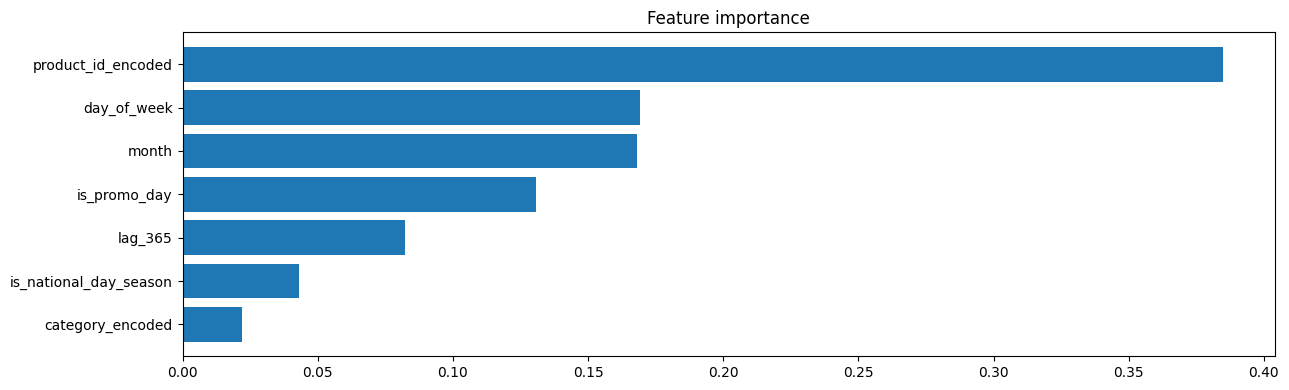

In [ ]:
# استخراج أهمية الخصائص من النموذج

importance = (
    pd.DataFrame({
        "feature": FEATURES,
        "importance": model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance)

plt.barh(importance["feature"][::-1], importance["importance"][::-1])
plt.title("Feature importance")
plt.tight_layout()
plt.show()

In [ ]:
# تقدير نطاق التنبؤ لكل منتج

tree_predictions = np.stack([
    tree.predict(test[FEATURES]).clip(0) for tree in model.estimators_
])

coverage_rows = []

for product in sorted(test["product_id"].unique()):
    mask = (test["product_id"] == product).values

    season_totals = tree_predictions[:, mask].sum(axis=1)
    lower, upper  = np.percentile(season_totals, [10, 90])
    actual        = test.loc[mask, "quantity"].sum()

    coverage_rows.append({
        "product_id": product,
        "actual":  int(actual),
        "lower":   int(lower),
        "upper":   int(upper),
        "covered": bool(lower <= actual <= upper),
    })

coverage = pd.DataFrame(coverage_rows)

display(coverage.head(10))
print("نسبة التغطية:", f"{coverage['covered'].mean():.0%}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWa

,product_id,actual,lower,upper,covered
0,P001,538,505,612,True
1,P002,758,630,736,False
2,P003,560,444,562,True
3,P004,471,415,529,True
4,P005,154,131,191,True
5,P006,160,113,163,True
6,P007,276,202,273,False
7,P008,196,146,200,True
8,P009,561,428,525,False
9,P010,337,250,330,False


نسبة التغطية: 62%


<div dir="rtl" style="text-align: right; line-height: 1.9;">

### قراءة النتيجة

يعرض الجدول النطاق المتوقع للطلب لكل منتج، ويبين ما إذا كانت القيمة الفعلية وقعت داخله خلال فترة الاختبار.

يستخدم هذا التحليل لفهم استقرار التنبؤات بصورة عامة، ولا يُعد ضمانًا لوقوع الطلب الفعلي داخل هذا النطاق.

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>الخلاصة</h2>

<p>
بُني نموذج للتنبؤ بالطلب على المنتجات بالاعتماد على البيانات التاريخية والخصائص المستخرجة منها، ثم جرى تقييم أدائه ومقارنته بالنموذج المرجعي، والتحقق من قدرته على التنبؤ قبل استخدامه لإصدار توقعات الموسم القادم.
</p>

<p>
أظهرت هذه المرحلة كيف يمكن تحويل بيانات المبيعات التاريخية إلى توقعات تدعم تخطيط المخزون وتساعد التاجر على اتخاذ قرارات أكثر دقة. وفي المرحلة التالية، سنستخدم النموذج لإصدار توقعات موسم اليوم الوطني 2026 وتحويلها إلى توصيات تشغيلية قابلة للتنفيذ.
</p>

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

## التنبؤ بالطلب لموسم 2026

بعد تقييم النموذج، نعيد تدريبه باستخدام جميع البيانات المتاحة حتى نهاية موسم 2025، ثم نستخدمه لإجراء التنبؤات لموسم اليوم الوطني 2026.

ولأن بيانات موسم 2026 غير متوفرة، سننشئ إطار بيانات جديدًا يمثل أيام الموسم مع استخدام الخصائص نفسها التي استُخدمت أثناء التدريب.

تعتمد التنبؤات النهائية على هذا النموذج، بينما تساعد نتائج التقييم السابقة في تقدير مستوى أدائه المتوقع.

</div>

In [ ]:
# نموذج التشغيل: يُعاد تدريبه على كامل البيانات المتاحة قبل التنبؤ

model_final = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model_final.fit(df[FEATURES], df[TARGET])

print("صفوف التدريب في نموذج التقييم :", f"{len(train):,}")
print("صفوف التدريب في نموذج التشغيل :", f"{len(df):,}")
print("مواسم يوم وطني شاهدها نموذج التشغيل: 2024 و 2025")

صفوف التدريب في نموذج التقييم : 10,522
صفوف التدريب في نموذج التشغيل : 18,547
مواسم يوم وطني شاهدها نموذج التشغيل: 2024 و 2025


In [ ]:
FORECAST_START = pd.Timestamp("2026-09-13")
FORECAST_END   = pd.Timestamp("2026-10-03")

future = pd.MultiIndex.from_product(
    [pd.date_range(FORECAST_START, FORECAST_END), products["product_id"]],
    names=["date", "product_id"]
).to_frame(index=False).merge(products, on="product_id")

future = future[future["date"] >= future["launch_date"]].copy()

future["day_of_week"]        = future["date"].dt.dayofweek
future["month"]              = future["date"].dt.month
future["product_id_encoded"] = future["product_id"].str[1:].astype(int)
future["category_encoded"]   = future["category"].astype("category").cat.codes

future["is_national_day_season"] = 1
# لا نفترض حملة ترويجية: النموذج يتنبأ بالطلب الأساسي
future["is_promo_day"] = 0

future = future.merge(lag, on=["date", "product_id"], how="left")
future["lag_365"] = future["lag_365"].fillna(-1)

print("عدد صفوف فترة التنبؤ:", future.shape[0])
print("منتجات بلا بيانات سابقة:",
      sorted(future.loc[future["lag_365"] == -1, "product_id"].unique()))

عدد صفوف فترة التنبؤ: 525
منتجات بلا بيانات سابقة: ['P025']


<div dir="rtl" style="text-align: right; line-height: 1.9;">

### افتراضات التنبؤ

التنبؤ هو الأساس الذي تُبنى عليه القرارات، وليس نتيجةً لها.
لذلك لا نفترض وجود حملة ترويجية مسبقًا، بل نتنبأ بالطلب الأساسي أولًا، ثم تُستخدم
هذه النتائج لاحقًا لاتخاذ قرارات التسويق، مثل اختيار موعد الحملة وتقدير الكميات المناسبة.

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

### تكلفة الخطأ بالريال

بعد إعداد التنبؤات، تأتي الخطوة التالية وهي تقدير الأثر المالي لأخطاء التنبؤ.

فالخطأ الناتج عن زيادة التقدير يختلف عن الخطأ الناتج عن نقصه؛ إذ تمثل الزيادة تكلفة مخزون إضافي، بينما يمثل النقص مبيعات مفقودة لا يمكن استعادتها بعد انتهاء الموسم.

</div>

In [ ]:
# الأثر المالي لخطأ النموذج على فترة الاختبار

test["error"]      = test["prediction"] - test[TARGET]
test["cost_price"] = test["product_id"].map(products.set_index("product_id")["cost_price"])
test["sale_price"] = test["product_id"].map(orders.groupby("product_id")["unit_price"].mean())

over  = test[test["error"] > 0]
under = test[test["error"] < 0]

overstock_cost = (over["error"] * over["cost_price"]).sum()
lost_revenue   = (-under["error"] * under["sale_price"]).sum()

print("أيام زاد فيها التقدير :", len(over), "|", f"{overstock_cost:,.0f}", "ريال")
print("أيام قلّ فيها التقدير :", len(under), "|", f"{lost_revenue:,.0f}", "ريال")
print("\nنسبة الفارق:", round(lost_revenue / overstock_cost, 1), "ضعفًا")

أيام زاد فيها التقدير : 233 | 25,358 ريال
أيام قلّ فيها التقدير : 271 | 89,667 ريال

نسبة الفارق: 3.5 ضعفًا


<div dir="rtl" style="text-align: right; line-height: 1.9;">

### قراءة النتيجة

توضح النتائج أن تكلفة نقص التقدير أعلى من تكلفة زيادته، لأن النقص يمثل مبيعات مفقودة، بينما تمثل الزيادة مخزونًا إضافيًا يمكن الاحتفاظ به.

لذلك سنضيف هامش أمان إلى الكمية المتوقعة عند إعداد توصية المخزون.

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>جدول المخزون</h2>

<p>
يمثل هذا الجدول أول مخرج تنفيذي للتنبؤات، إذ يحول الطلب المتوقع إلى كميات مخزون مقترحة يمكن للتاجر الاستفادة منها عند التخطيط للموسم. ويعرض الجدول الطلب المتوقع لكل منتج، والكمية الموصى بها بعد إضافة هامش أمان قدره <strong>15%</strong>، إلى جانب التكلفة التقديرية ومستوى الثقة.
</p>



</div>

In [ ]:
# TODO 11:
# جدول المخزون: مستوى المخزون الموصى به لكل منتج

SAFETY = 1.15

future["prediction"] = model_final.predict(future[FEATURES]).clip(0)

stock = (
    future.groupby("product_id", as_index=False)["prediction"].sum()
          .rename(columns={"prediction": "predicted_demand"})
          .merge(products[["product_id", "product_name", "cost_price"]], on="product_id")
)

stock["predicted_demand"] = stock["predicted_demand"].round().astype(int)
# ← نسبة هامش الأمان
stock["recommended_stock"] = (stock["predicted_demand"] * ______).round().astype(int)


stock["estimated_cost"]    = stock["recommended_stock"] * stock["____________"]

stock["mape"]             = stock["product_id"].map(per_product_mape).round(1).fillna(99.9)

# ← الحد الفاصل لمستوى الثقة
stock["confidence"]        = np.where(stock["mape"] < ____, "high", "low")

print("إجمالي الطلب المتوقع:", f"{stock['predicted_demand'].sum():,}", "وحدة")
print("التكلفة التقديرية  :", f"{stock['estimated_cost'].sum():,}", "ريال")

display(stock.sort_values("predicted_demand", ascending=False))

إجمالي الطلب المتوقع: 6,792 وحدة
التكلفة التقديرية  : 185,597 ريال


,product_id,predicted_demand,product_name,cost_price,recommended_stock,estimated_cost,mape,confidence
1,P002,531,Saudi flag (desk size),5,611,3055,9.6,high
2,P003,450,Green LED string lights 10m,14,518,7252,10.1,high
8,P009,399,SA flag mug,10,459,4590,15.2,high
0,P001,389,"Saudi flag (large, outdoor)",18,447,8046,4.2,high
11,P012,342,Personalized keychain (name),8,393,3144,10.3,high
22,P023,321,Green LED wristbands (5-pack),5,369,1845,14.7,high
16,P017,304,'KSA 96' t-shirt,20,350,7000,19.7,high
3,P004,304,National Day balloon & banner kit,22,350,7700,0.3,high
19,P020,291,Face-paint & stickers pack,7,335,2345,4.8,high
18,P019,276,Green cap (embroidered),16,317,5072,20.6,high


<div dir="rtl" style="text-align: right; line-height: 1.9;">

### تصحيح تقدير المنتج حديث الإطلاق

لا يملك المنتج <code>P025</code> تاريخًا موسميًا سابقًا، لذلك لا يكون تقدير النموذج له موثوقًا بالدرجة نفسها التي تكون عليها المنتجات الأقدم.

لهذا سنستبدل تقديره بقياس مستند إلى متوسط مبيعاته الحديثة، مع الإبقاء على مستوى الثقة منخفضًا.

</div>

In [ ]:
# تطبيق تقدير القياس على المنتج حديث الإطلاق

NEW_PRODUCT = "P025"

# المتوسط يُحسب من جدول التحليل الكامل ليشمل الأيام التي لم يُبع فيها المنتج
recent_daily = df.loc[(df["product_id"] == NEW_PRODUCT)
                      & df["date"].between("2026-07-01", "2026-08-10"),
                      "quantity"].mean()

season_days = (FORECAST_END - FORECAST_START).days + 1
analogy_estimate = int(round(recent_daily * season_multiplier * season_days))

model_estimate = int(stock.loc[stock["product_id"] == NEW_PRODUCT, "predicted_demand"].iloc[0])

print("تقدير النموذج      :", model_estimate, "وحدة")
print("تقدير القياس بالفئة:", analogy_estimate, "وحدة")

stock.loc[stock["product_id"] == NEW_PRODUCT, "predicted_demand"] = analogy_estimate
stock.loc[stock["product_id"] == NEW_PRODUCT, "recommended_stock"] = \
    int(round(analogy_estimate * SAFETY))
stock.loc[stock["product_id"] == NEW_PRODUCT, "confidence"] = "low"
stock["estimated_cost"] = stock["recommended_stock"] * stock["cost_price"]

display(stock[stock["product_id"] == NEW_PRODUCT])

# إعادة حساب الإجماليات بعد التصحيح
print("\nبعد تصحيح المنتج حديث الإطلاق:")
print("إجمالي الطلب المتوقع:", f"{stock['predicted_demand'].sum():,}", "وحدة")
print("التكلفة التقديرية  :", f"{stock['estimated_cost'].sum():,}", "ريال")

تقدير النموذج      : 248 وحدة
تقدير القياس بالفئة: 397 وحدة


,product_id,predicted_demand,product_name,cost_price,recommended_stock,estimated_cost,mape,confidence
24,P025,397,Projection lamp (KSA landmarks),58,457,26506,99.9,low



بعد تصحيح المنتج حديث الإطلاق:
إجمالي الطلب المتوقع: 6,941 وحدة
التكلفة التقديرية  : 195,573 ريال


<div dir="rtl" style="text-align: right; line-height: 1.9;">

### قراءة النتيجة

اختلف التقدير الجديد عن تقدير النموذج لأنه يعتمد على مبيعات المنتج الحديثة بدلًا من موسم سابق غير متوفر.

ويظل هذا التقدير أوليًا، لذلك يُصنف المنتج ضمن مستوى الثقة المنخفض.

</div>

<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h3>قيد الميزانية (اختياري)</h3>

<p>
بعد تحديد الكميات الموصى بها للموسم، لنفترض أن التاجر خصص ميزانية قدرها <strong>50,000 ريال</strong> لتجهيز المخزون، في حين تتجاوز تكلفة توفير جميع الكميات المقترحة هذا المبلغ.
</p>

<p>
أمامك الآن نتائج التنبؤ، والكميات الموصى بها، وتكلفة كل منتج. استخدم هذه المعلومات لوضع خطة شراء لا تتجاوز الميزانية المتاحة، مع تحديد الكمية النهائية لكل منتج.
</p>

<p>
<strong>
ما الخطة التي ستقترحها للتاجر؟ حدّد طريقة توزيع الميزانية، ووضّح كيف استفدت من نتائج التنبؤ في تحديد الكميات النهائية.
</strong>
</p>

</div>

In [ ]:
# قيد الميزانية (اختياري)
# ضع خطة لتوزيع الميزانية على المنتجات، وحدّد الكميات النهائية المقترحة.

BUDGET = 50000

# ابدأ الحل هنا

الأسلوب الأول — مُموَّل: 12 منتج | 49,325 ريال
P004 مُموَّل؟ False

الأسلوب الثاني — الإنفاق: 49,598 ريال
P004 مُموَّل؟ True


<div dir="rtl" style="text-align: right; line-height: 1.9;">

<h2>مذكرة التوصية</h2>

<p>
تنتهي دراسة الحالة بتحويل نتائج التحليل والتنبؤ إلى توصية عملية تساعد التاجر على اتخاذ قرار مدروس بشأن المخزون والميزانية.
</p>

<p>
تُلخّص مذكرة التوصية أهم النتائج، وتوضح الكميات المقترحة لكل منتج، وموعد إطلاق الحملة، وطريقة توزيع الميزانية، إلى جانب أبرز الافتراضات والقيود التي ينبغي أخذها في الاعتبار قبل تنفيذ القرار.
</p>

</div>

In [ ]:
# مذكرة التوصية
# اكتب المذكرة الموجّهة إلى التاجر، وتتضمن:
# 1- وصفًا موجزًا لما تم تنفيذه.
# 2- أبرز ثلاث نتائج مستخلصة من التحليل.
# 3- الكميات الموصى بطلبها ونسبة الأمان المعتمدة مع مبررها.
# 4- تاريخ إطلاق الحملة الترويجية مع مبرره من البيانات.
# 5- حدود النموذج والحالات التي لا يمكن التنبؤ بها.

recommendation_memo = """

"""

print(recommendation_memo)

In [ ]:
  import json

  dashboard_products = [
      {
          "name": str(row["product_name"]),
          "predicted": int(round(row["predicted_demand"])),
          "recommended": int(round(row["recommended_stock"])),
          "cost": float(row["estimated_cost"]),
          "confidence": str(row["confidence"]),
      }
      for _, row in stock.iterrows()
  ]

  dashboard_payload = {
      "metrics": {
          "mae": float(mae),
          "rmse": 0,
          "mape": float(model_mape),
          "value_at_risk": 0,
          "recommended_units": int(round(stock["recommended_stock"].sum())),
          "estimated_cost": float(stock["estimated_cost"].sum()),
      },
      "products": dashboard_products,
      "importances": importance[
          ["feature", "importance"]
      ].to_dict(orient="records"),
      "launch_date": str(ramp_up_day.date()),
      "notes": recommendation_memo.strip(),
  }

  print("BEYOND_DASHBOARD_JSON_BEGIN")
  print(json.dumps(dashboard_payload, ensure_ascii=False))
  print("BEYOND_DASHBOARD_JSON_END")